# 03 - Data Exploration

Goal: build actual intuition for what's in this dataset before going back
to `02_feature_engineering.ipynb` armed with context -- trajectory lengths,
geographic spread, feature distributions, correlations, and whether early
features show any natural clustering that lines up with severity_class.

In [1]:
import sys
sys.path.insert(0, "../src")

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from flashpoint.db import get_connection

DB_PATH = Path("../data/flashpoint.duckdb")
con = get_connection(DB_PATH)

events_df = con.execute("SELECT * FROM events").df()
outcomes_df = con.execute("SELECT * FROM event_outcomes").df()
features_df = con.execute("SELECT * FROM early_features").df()
full_df = con.execute("""
    SELECT e.year, e.centroid_lon, e.centroid_lat, e.n_days, f.*, o.max_area_ha, o.severity_class
    FROM events e
    JOIN early_features f ON f.event_id = e.event_id
    JOIN event_outcomes o ON o.event_id = e.event_id
""").df()
print(f"{len(events_df)} events total, {len(full_df)} with early features + outcomes")

607 events total, 607 with early features + outcomes


## What's a "typical" fire trajectory?

`n_days` includes the 4 buffer days added before and after each fire's
official GlobFire dates (per the paper), so this is somewhat longer than
the fire's actual active duration -- but still the right number to look at
for "how many days of data does a typical event give us."

count    607.000000
mean      22.416804
std       10.724540
min        9.000000
25%       15.000000
50%       19.000000
75%       26.000000
max       94.000000
Name: n_days, dtype: float64


Text(0.5, 1.0, 'Fire trajectory length')

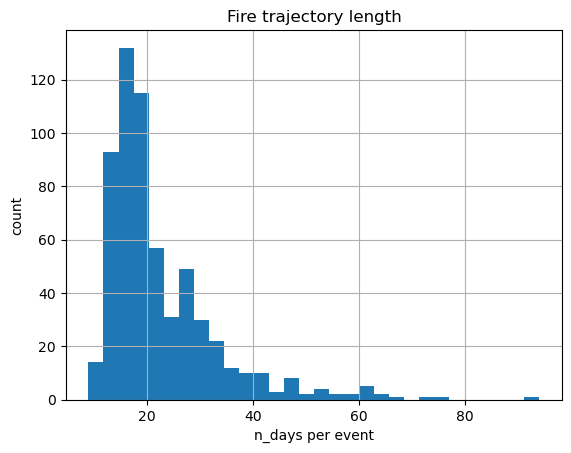

In [2]:
print(events_df['n_days'].describe())
events_df['n_days'].hist(bins=30)
plt.xlabel('n_days per event')
plt.ylabel('count')
plt.title('Fire trajectory length')

## Events per year, and where they are geographically

2019 is the known outlier year (paper reports 74 fires vs. 150-200 in
other years) -- worth seeing that directly rather than just taking it on
faith.

year
2018    176
2019     74
2020    201
2021    156
Name: count, dtype: int64


/Users/pmacias/opt/anaconda3/envs/flashpoint/lib/python3.11/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_1_states_provinces_lakes.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/Users/pmacias/opt/anaconda3/envs/flashpoint/lib/python3.11/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/Users/pmacias/opt/anaconda3/envs/flashpoint/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/pmacias/opt/anaconda3/envs/flashpoint/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), ou

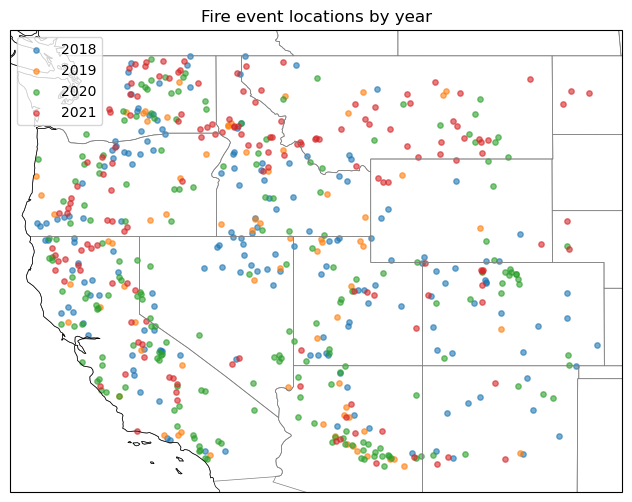

In [3]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

print(events_df['year'].value_counts().sort_index())

extent = [
    events_df['centroid_lon'].min() - 1, events_df['centroid_lon'].max() + 1,
    events_df['centroid_lat'].min() - 1, events_df['centroid_lat'].max() + 1,
]

fig, ax = plt.subplots(figsize=(8, 6), subplot_kw={'projection': ccrs.PlateCarree()})
ax.add_feature(cfeature.STATES, linewidth=0.5, edgecolor='gray')
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.set_extent(extent, crs=ccrs.PlateCarree())

for year, group in events_df.groupby('year'):
    ax.scatter(group['centroid_lon'], group['centroid_lat'], label=str(year),
               alpha=0.6, s=15, transform=ccrs.PlateCarree())
ax.set_title('Fire event locations by year')
ax.legend()

## Does geography relate to severity?

Same scatter, colored by severity_class instead of year -- worth checking
whether big fires cluster in particular regions (which would suggest
location/terrain matters more than day-1/day-2 weather alone).

/Users/pmacias/opt/anaconda3/envs/flashpoint/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/pmacias/opt/anaconda3/envs/flashpoint/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/pmacias/opt/anaconda3/envs/flashpoint/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)


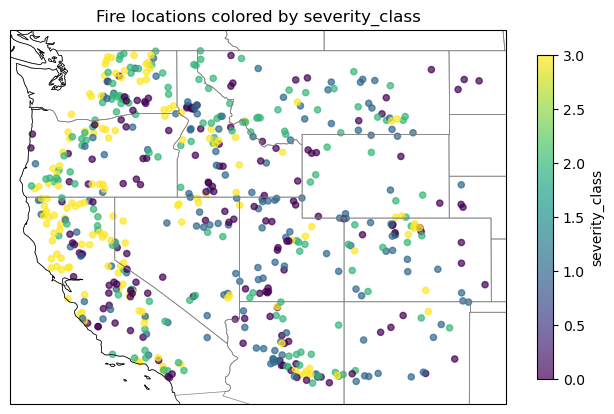

In [4]:
fig, ax = plt.subplots(figsize=(8, 6), subplot_kw={'projection': ccrs.PlateCarree()})
ax.add_feature(cfeature.STATES, linewidth=0.5, edgecolor='gray')
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.set_extent(extent, crs=ccrs.PlateCarree())

sc = ax.scatter(full_df['centroid_lon'], full_df['centroid_lat'],
                 c=full_df['severity_class'], cmap='viridis', alpha=0.7, s=20,
                 transform=ccrs.PlateCarree())
ax.set_title('Fire locations colored by severity_class')
plt.colorbar(sc, label='severity_class', ax=ax, shrink=0.7)

## Early feature distributions

One histogram per feature -- worth a quick look for anything oddly-shaped
(bimodal, heavily skewed, suspicious spikes at a boundary value) before
trusting a model's use of it.

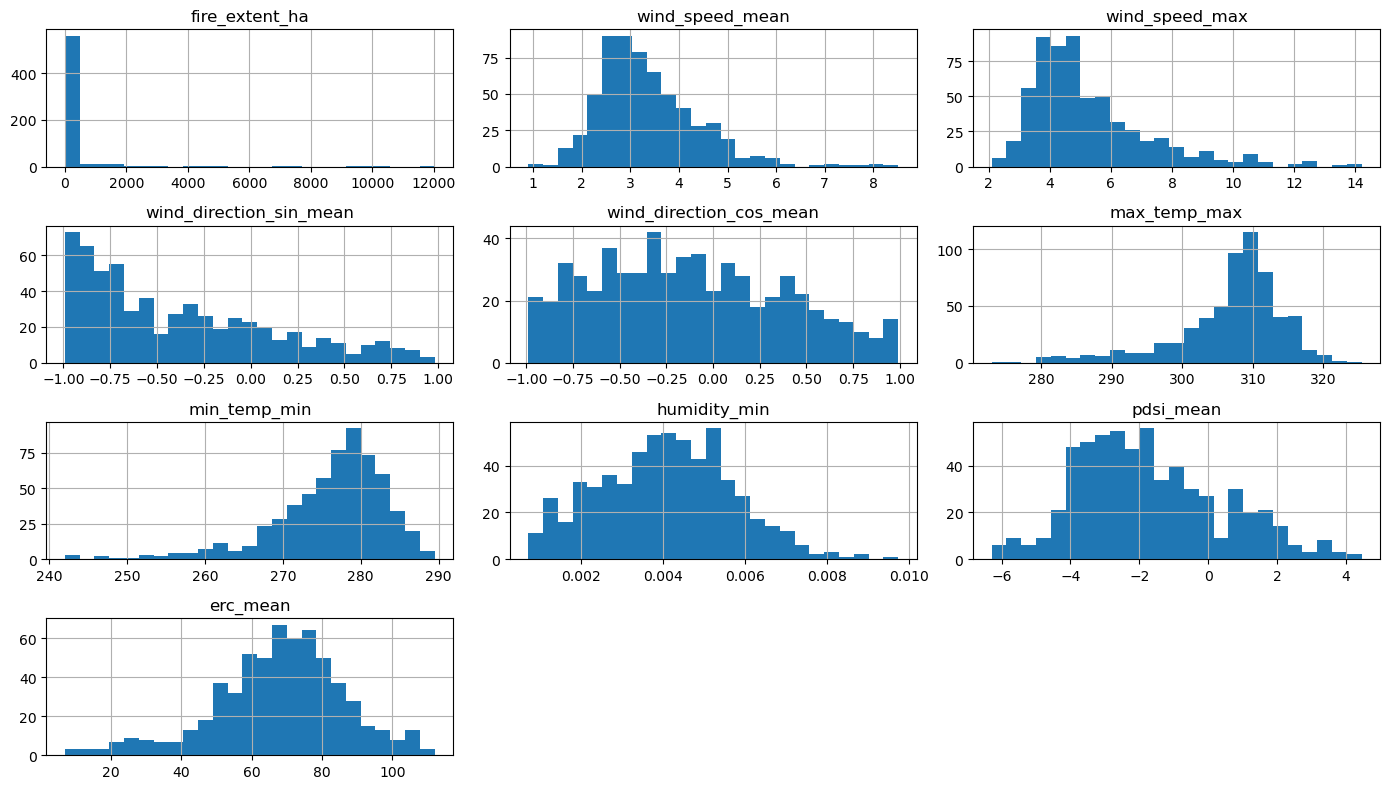

In [5]:
FEATURE_COLS = [
    "fire_extent_ha", "wind_speed_mean", "wind_speed_max",
    "wind_direction_sin_mean", "wind_direction_cos_mean",
    "max_temp_max", "min_temp_min", "humidity_min", "pdsi_mean", "erc_mean",
]

full_df[FEATURE_COLS].hist(figsize=(14, 8), bins=25)
plt.tight_layout()

## Feature correlations

Worth checking before trusting SHAP rankings too literally -- if two
features are highly correlated, SHAP can split "credit" between them in
ways that make either look less important than the pair really is.

Text(0.5, 1.0, 'Early feature correlation matrix')

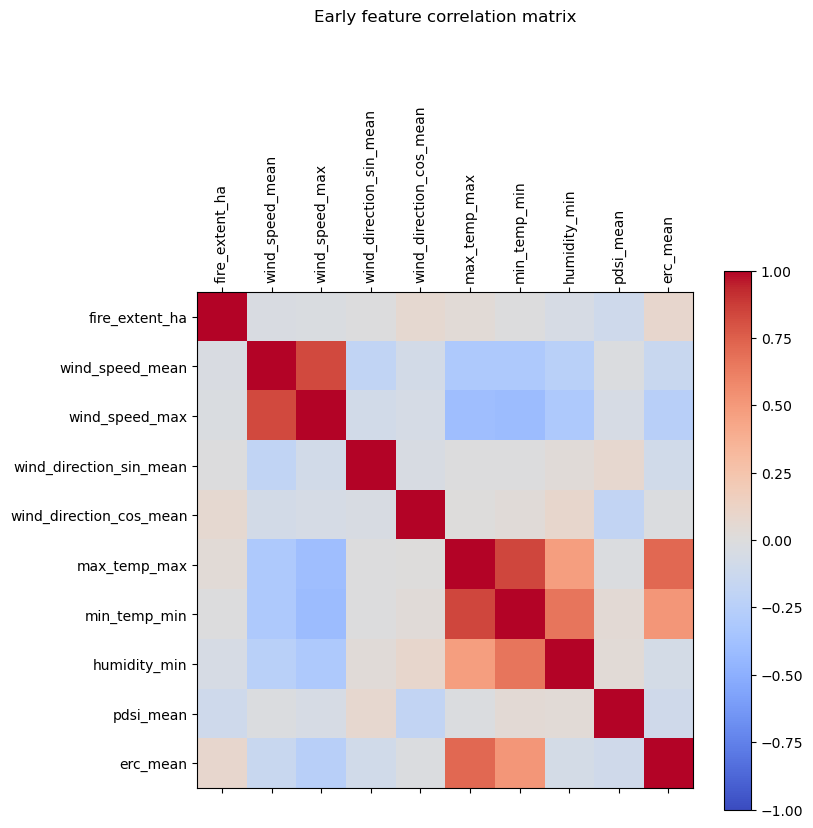

In [6]:
corr = full_df[FEATURE_COLS].corr()
fig, ax = plt.subplots(figsize=(8, 7))
im = ax.matshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(FEATURE_COLS)))
ax.set_yticks(range(len(FEATURE_COLS)))
ax.set_xticklabels(FEATURE_COLS, rotation=90)
ax.set_yticklabels(FEATURE_COLS)
plt.colorbar(im)
plt.title('Early feature correlation matrix', pad=60)

## Do features separate by severity class at all?

Boxplots of each feature, split by severity_class -- a visual gut check
for whether the classes are separable BEFORE trusting a model's accuracy
number to tell you that story.

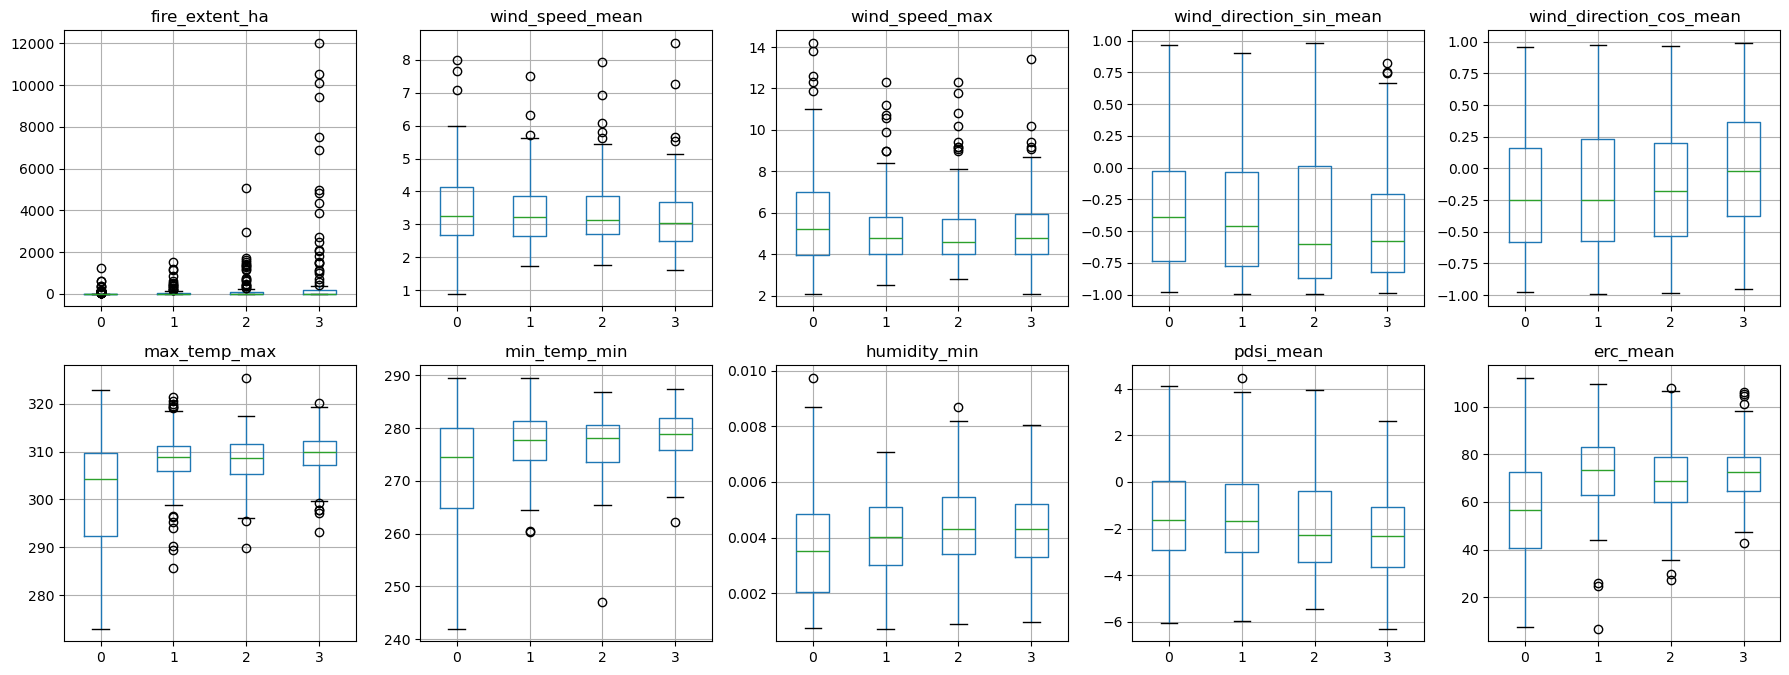

In [7]:
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
for ax, col in zip(axes.flat, FEATURE_COLS):
    full_df.boxplot(column=col, by='severity_class', ax=ax)
    ax.set_title(col)
    ax.set_xlabel('')
plt.suptitle('')
plt.tight_layout()

## Natural clusters in early-feature space

PCA down to 2D + KMeans, purely exploratory -- do events form natural
groupings in early-feature space at all, and if so, do those groupings
line up with severity_class (colored) or cut across it?

Explained variance (2 PCs): 0.47


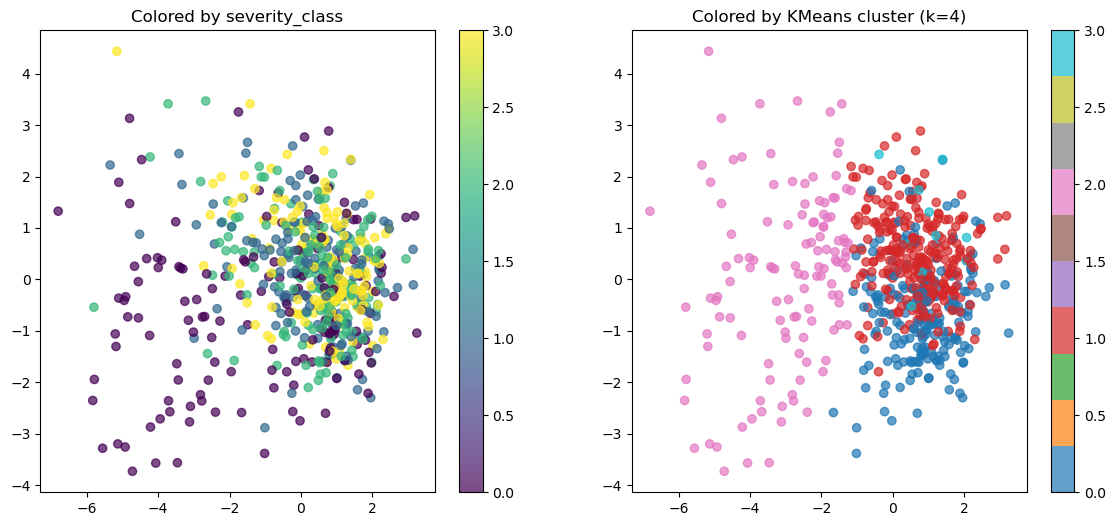

In [8]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

X = StandardScaler().fit_transform(full_df[FEATURE_COLS])
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
print(f"Explained variance (2 PCs): {pca.explained_variance_ratio_.sum():.2f}")

kmeans = KMeans(n_clusters=4, random_state=0, n_init=10)
cluster_labels = kmeans.fit_predict(X)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sc0 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=full_df['severity_class'], cmap='viridis', alpha=0.7)
axes[0].set_title('Colored by severity_class')
plt.colorbar(sc0, ax=axes[0])

sc1 = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, cmap='tab10', alpha=0.7)
axes[1].set_title('Colored by KMeans cluster (k=4)')
plt.colorbar(sc1, ax=axes[1])

## Takeaways to bring back into 02

Fill in after running the above:
- Typical trajectory length: ?
- Is 2019 geographically different, or just smaller/fewer fires in the same places?
- Any features that look bimodal/suspicious in their raw distribution?
- Any pair of features highly correlated enough to reconsider dropping one?
- Do the boxplots show ANY visual separation by severity_class, even where
  accuracy is modest -- that would support "real but weak signal" over
  "no signal at all"
- Do PCA/KMeans clusters cut across severity_class (suggesting the natural
  groupings in the data are about something else, e.g. region or season) or
  align with it?

## Actual fire trajectories over time

Active-fire extent per day, for a sample of events stratified by severity
class -- do severe fires spike early and stay high, ignite late, or
oscillate, versus small/contained ones staying flat near zero throughout?

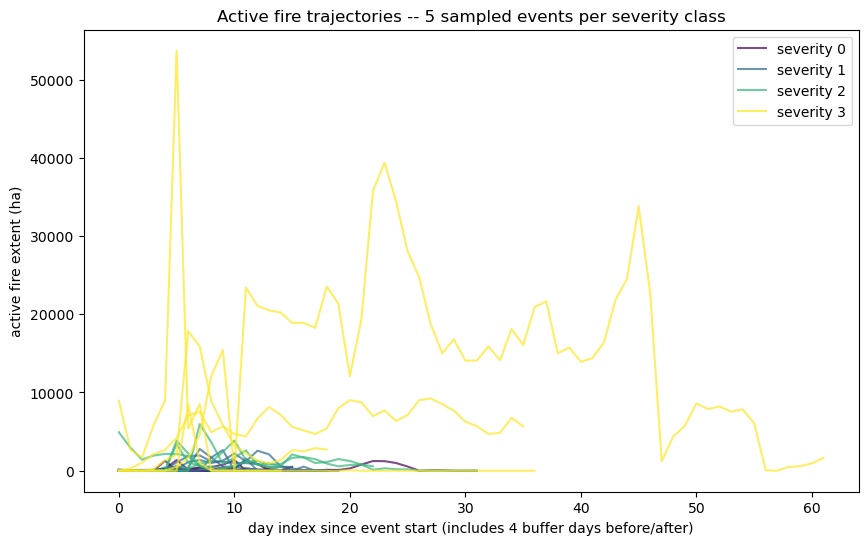

In [9]:
import numpy as np
from flashpoint.data_access import HDF5Event, read_channel_all_days, ACTIVE_FIRE_CHANNEL_IDX, PIXEL_AREA_HA

N_PER_CLASS = 5  # bump up for more lines, or set to None below to plot everything

plot_df = con.execute("""
    SELECT e.event_id, e.hdf5_path, e.n_days, o.severity_class
    FROM events e JOIN event_outcomes o ON o.event_id = e.event_id
    WHERE o.severity_class IS NOT NULL
""").df()

sample_df = pd.concat([
    g.sample(min(N_PER_CLASS, len(g)), random_state=0)
    for _, g in plot_df.groupby('severity_class')
], ignore_index=True)

fig, ax = plt.subplots(figsize=(10, 6))
cmap = plt.cm.viridis
seen_classes = set()

for _, row in sample_df.iterrows():
    event = HDF5Event(
        event_id=row['event_id'], year=0, hdf5_path=Path(row['hdf5_path']),
        n_days=row['n_days'], img_dates=[], lnglat=(0, 0),
    )
    af_all_days = read_channel_all_days(event, ACTIVE_FIRE_CHANNEL_IDX)
    area_per_day = (af_all_days > 0).reshape(af_all_days.shape[0], -1).sum(axis=1) * PIXEL_AREA_HA

    cls = row['severity_class']
    label = f"severity {cls}" if cls not in seen_classes else None
    seen_classes.add(cls)
    ax.plot(range(len(area_per_day)), area_per_day,
            color=cmap(cls / plot_df['severity_class'].max()), alpha=0.7, label=label)

ax.set_xlabel('day index since event start (includes 4 buffer days before/after)')
ax.set_ylabel('active fire extent (ha)')
ax.set_title(f'Active fire trajectories -- {N_PER_CLASS} sampled events per severity class')
ax.legend()

## Same trajectories, split into 4 panels with independent y-axes

A shared y-axis buries small/contained fires under the largest ones --
one panel per severity class, each auto-scaled to its own data, shows
the shape of each tier properly.

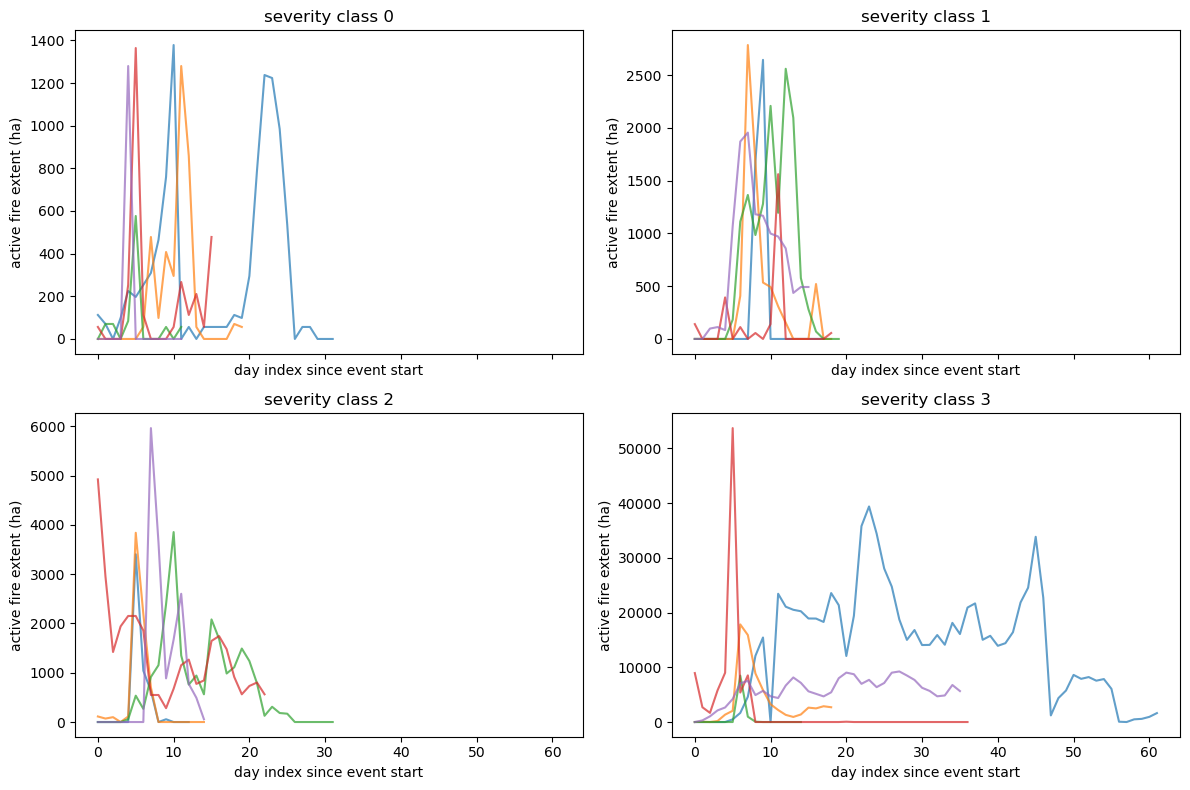

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
axes = axes.flatten()

for cls in sorted(plot_df['severity_class'].unique()):
    ax = axes[cls]
    class_events = plot_df[plot_df['severity_class'] == cls]
    sample = class_events.sample(min(N_PER_CLASS, len(class_events)), random_state=0)

    for _, row in sample.iterrows():
        event = HDF5Event(
            event_id=row['event_id'], year=0, hdf5_path=Path(row['hdf5_path']),
            n_days=row['n_days'], img_dates=[], lnglat=(0, 0),
        )
        af_all_days = read_channel_all_days(event, ACTIVE_FIRE_CHANNEL_IDX)
        area_per_day = (af_all_days > 0).reshape(af_all_days.shape[0], -1).sum(axis=1) * PIXEL_AREA_HA
        ax.plot(range(len(area_per_day)), area_per_day, alpha=0.7)

    ax.set_title(f'severity class {cls}')
    ax.set_xlabel('day index since event start')
    ax.set_ylabel('active fire extent (ha)')

plt.tight_layout()